Obstacle Density Levels
1 -> Low
2 -> Medium
3 -> High


Enter your choice:  2
Enter start row (0 to 69):  12
Enter start column (0 to 69):  34
Enter goal row (0 to 69):  4
Enter goal column (0 to 69):  6



----- Output -----
Grid size             : 70 x 70
Obstacle level        : Medium
Start node            : (12, 34)
Goal node             : (4, 6)
Nodes explored        : 1668
Execution time        : 0.018885 seconds
Path found            : Yes
Shortest distance     : 31.31
Number of cells in path: 29
Path traced           :
[(12, 34), (11, 33), (11, 32), (11, 31), (11, 30), (11, 29), (11, 28), (11, 27), (11, 26), (11, 25), (11, 24), (11, 23), (11, 22), (11, 21), (11, 20), (11, 19), (11, 18), (11, 17), (11, 16), (11, 15), (11, 14), (10, 13), (9, 12), (8, 11), (7, 10), (6, 9), (6, 8), (5, 7), (4, 6)]


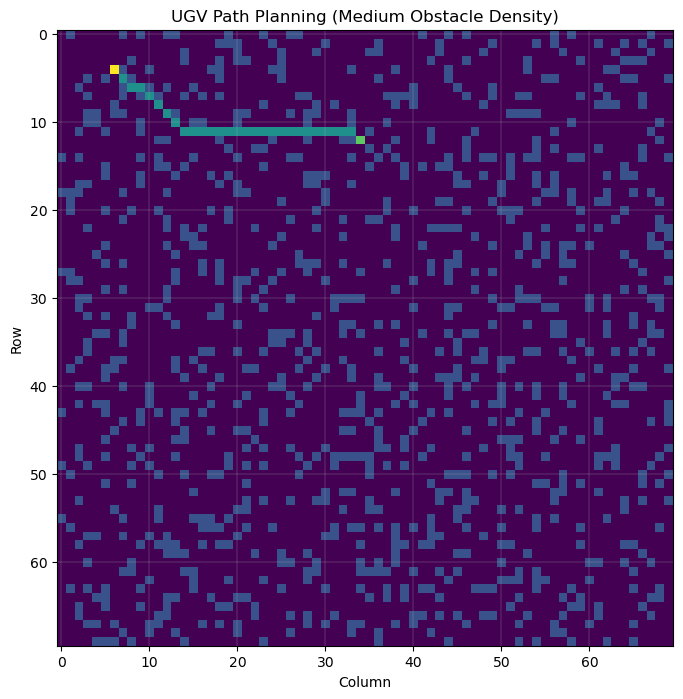

In [1]:
import heapq
import random
import math
import time
import matplotlib.pyplot as plt
import numpy as np

# cell types
EMPTY = 0
BLOCK = 1
ROUTE = 2
SRC = 3
DEST = 4


def make_battlefield(n, density, start, goal):
    grid = [[0 for _ in range(n)] for _ in range(n)]

    for i in range(n):
        for j in range(n):
            if random.random() < density:
                grid[i][j] = BLOCK

    sx, sy = start
    gx, gy = goal

    grid[sx][sy] = EMPTY
    grid[gx][gy] = EMPTY

    return grid


def valid_moves(x, y, n):
    steps = [
        (-1, 0), (1, 0), (0, -1), (0, 1),
        (-1, -1), (-1, 1), (1, -1), (1, 1)
    ]

    ans = []
    for dx, dy in steps:
        nx = x + dx
        ny = y + dy
        if 0 <= nx < n and 0 <= ny < n:
            ans.append((nx, ny))
    return ans


def step_cost(x1, y1, x2, y2):
    if abs(x1 - x2) == 1 and abs(y1 - y2) == 1:
        return math.sqrt(2)
    return 1


def shortest_path(grid, start, goal):
    n = len(grid)

    dist = [[float("inf")] * n for _ in range(n)]
    parent = [[None] * n for _ in range(n)]
    done = [[False] * n for _ in range(n)]

    sx, sy = start
    gx, gy = goal

    pq = []
    heapq.heappush(pq, (0, sx, sy))
    dist[sx][sy] = 0

    explored = 0

    while pq:
        curr_d, x, y = heapq.heappop(pq)

        if done[x][y]:
            continue

        done[x][y] = True
        explored += 1

        if (x, y) == (gx, gy):
            break

        for nx, ny in valid_moves(x, y, n):
            if grid[nx][ny] == BLOCK:
                continue

            new_d = curr_d + step_cost(x, y, nx, ny)

            if new_d < dist[nx][ny]:
                dist[nx][ny] = new_d
                parent[nx][ny] = (x, y)
                heapq.heappush(pq, (new_d, nx, ny))

    if dist[gx][gy] == float("inf"):
        return None, None, explored

    path = []
    cur = (gx, gy)
    while cur is not None:
        path.append(cur)
        px, py = cur
        cur = parent[px][py]

    path.reverse()
    return path, dist[gx][gy], explored


def draw_result(grid, path, start, goal, level_name):
    n = len(grid)
    show = [row[:] for row in grid]

    if path is not None:
        for x, y in path:
            if (x, y) != start and (x, y) != goal:
                show[x][y] = ROUTE

    sx, sy = start
    gx, gy = goal
    show[sx][sy] = SRC
    show[gx][gy] = DEST

    arr = np.array(show)

    plt.figure(figsize=(8, 8))
    plt.imshow(arr)
    plt.title(f"UGV Path Planning ({level_name} Obstacle Density)")
    plt.xlabel("Column")
    plt.ylabel("Row")
    plt.grid(True, linewidth=0.2)
    plt.show()


def main():
    size = 70

    levels = {
        "1": ("Low", 0.10),
        "2": ("Medium", 0.20),
        "3": ("High", 0.30)
    }

    print("Obstacle Density Levels")
    print("1 -> Low")
    print("2 -> Medium")
    print("3 -> High")

    ch = input("Enter your choice: ").strip()

    if ch not in levels:
        print("Invalid choice")
        return

    level_name, density = levels[ch]

    try:
        sx = int(input("Enter start row (0 to 69): "))
        sy = int(input("Enter start column (0 to 69): "))
        gx = int(input("Enter goal row (0 to 69): "))
        gy = int(input("Enter goal column (0 to 69): "))
    except ValueError:
        print("Please enter integer values only")
        return

    if not (0 <= sx < size and 0 <= sy < size and 0 <= gx < size and 0 <= gy < size):
        print("Start or goal is outside the grid")
        return

    start = (sx, sy)
    goal = (gx, gy)

    random.seed(42)
    field = make_battlefield(size, density, start, goal)

    t1 = time.time()
    path, cost, explored = shortest_path(field, start, goal)
    t2 = time.time()

    print("\n----- Output -----")
    print("Grid size             :", size, "x", size)
    print("Obstacle level        :", level_name)
    print("Start node            :", start)
    print("Goal node             :", goal)
    print("Nodes explored        :", explored)
    print("Execution time        :", round(t2 - t1, 6), "seconds")

    if path is None:
        print("Path found            : No")
        print("Shortest distance     : Not reachable")
    else:
        print("Path found            : Yes")
        print("Shortest distance     :", round(cost, 2))
        print("Number of cells in path:", len(path))
        print("Path traced           :")
        print(path)

    draw_result(field, path, start, goal, level_name)


if __name__ == "__main__":
    main()